# UG-CPPO: Uncertainty-Gated LLM Infusion for Risk-Sensitive Trading Agents
**FinAI Contest 2025 — Task 1** · Grace Esther · Société Générale

---
### 3 bugs corrigés vs. version précédente
| Bug | Symptôme | Fix |
|-----|----------|-----|
| Cell 4b: `.count(0)` sur arrays | `ValueError: truth value ambiguous` | Remplacé par stats numpy |
| `signal_df=None` → agents identiques | 3 courbes superposées | Mock signals générés si FNSPID absent |
| 50k steps → agents passifs | Actions ≈ 0, courbes plates | Réduit à 20 tickers + 200k steps + reward scaling |


## 0a. Install & Setup

In [1]:
%%capture
!pip install finrl stable-baselines3[extra] gymnasium yfinance stockstats
!pip install openai anthropic python-dotenv pyyaml tqdm pyfolio-reloaded huggingface_hub

In [2]:
import os, sys
from pathlib import Path

REPO_URL = 'https://github.com/graceesthi/ug_cppo.git'

current = Path.cwd()
project_root = None
if (current / 'src').exists():
    project_root = current
elif (current.parent / 'src').exists():
    project_root = current.parent

if project_root:
    os.chdir(project_root)
    print(f'✓ Project found at: {project_root}')
else:
    if not Path('ug_cppo').exists():
        print(f'Cloning {REPO_URL}...')
        os.system(f'git clone {REPO_URL}')
    os.chdir('ug_cppo')
    project_root = Path.cwd()

sys.path.insert(0, str(project_root))
os.makedirs('data', exist_ok=True)
os.makedirs('results/models', exist_ok=True)
os.makedirs('results/tensorboard', exist_ok=True)
print(f'Working from: {os.getcwd()}')

✓ Project found at: /Users/grace/Downloads/ug_cppo
Working from: /Users/grace/Downloads/ug_cppo


## 0b. Configure LLM provider

In [3]:
LLM_PROVIDER = 'openai'   # 'mock' | 'openai' | 'anthropic'

from dotenv import load_dotenv
load_dotenv(dotenv_path=Path(project_root) / '.env')

if LLM_PROVIDER == 'openai':
    api_key = os.environ.get('OPENAI_API_KEY', '')
    if not api_key:
        # Colab fallback
        try:
            from google.colab import userdata
            os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
        except Exception:
            raise ValueError('OPENAI_API_KEY not found. Set in .env or Colab secrets.')
    LLM_MODEL = 'gpt-4o-mini'
    print(f'✓ OpenAI / {LLM_MODEL}')

elif LLM_PROVIDER == 'anthropic':
    api_key = os.environ.get('ANTHROPIC_API_KEY', '')
    if not api_key:
        try:
            from google.colab import userdata
            os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')
        except Exception:
            raise ValueError('ANTHROPIC_API_KEY not found.')
    LLM_MODEL = 'claude-haiku-4-5-20251001'
    print(f'✓ Anthropic / {LLM_MODEL}')

else:
    LLM_MODEL = 'mock'
    print('✓ Mock LLM — aucun appel API, heuristiques par mots-clés')

from src.uncertainty_llm import LLMConfig
if LLM_PROVIDER == 'openai':
    llm_config = LLMConfig.openai(model=LLM_MODEL)
elif LLM_PROVIDER == 'anthropic':
    llm_config = LLMConfig.anthropic(model=LLM_MODEL)
else:
    llm_config = LLMConfig.mock()

✓ OpenAI / gpt-4o-mini


## 1. Visualise the Uncertainty Gate

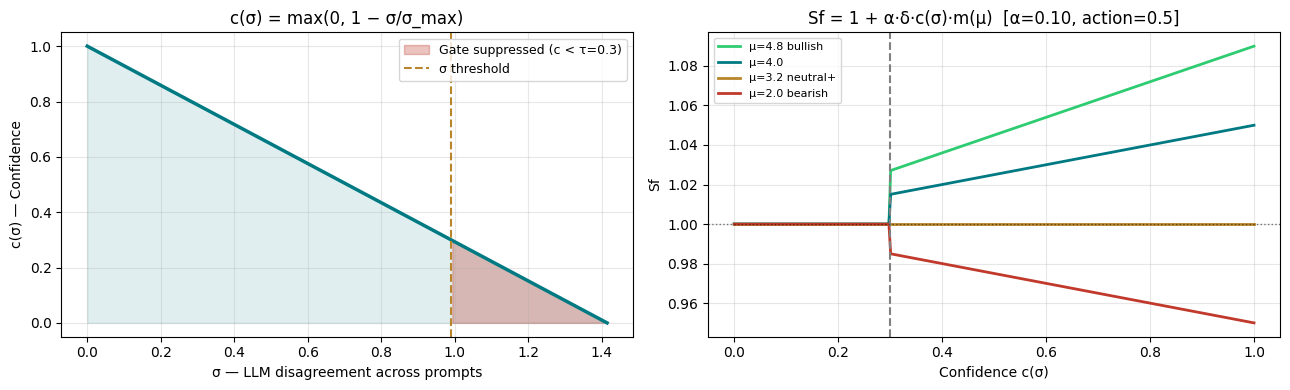

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from src.uncertainty_llm import UncertaintyAwareLLM, compute_sf, SIGMA_MAX

sigmas = np.linspace(0, SIGMA_MAX, 300)
confs  = np.maximum(0, 1 - sigmas / SIGMA_MAX)
TAU    = 0.30

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(sigmas, confs, lw=2.5, color='#007A82')
ax.fill_between(sigmas, confs, alpha=0.12, color='#007A82')
ax.fill_between(sigmas, confs, where=(confs < TAU),
                alpha=0.30, color='#C0392B', label=f'Gate suppressed (c < τ={TAU})')
ax.axvline(x=SIGMA_MAX*(1-TAU), ls='--', color='#B8852A', lw=1.5, label=f'σ threshold')
ax.set_xlabel('σ — LLM disagreement across prompts'); ax.set_ylabel('c(σ) — Confidence')
ax.set_title('c(σ) = max(0, 1 − σ/σ_max)'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
for mu, col, lbl in [(4.8,'#2ECC71','μ=4.8 bullish'), (4.0,'#007A82','μ=4.0'),
                     (3.2,'#B8852A','μ=3.2 neutral+'), (2.0,'#C0392B','μ=2.0 bearish')]:
    sfs = [compute_sf(mu, c, action=0.5, alpha=0.10, tau=TAU)[0] for c in confs]
    ax.plot(confs, sfs, lw=2, color=col, label=lbl)
ax.axvline(x=TAU, ls='--', color='gray', lw=1.5)
ax.axhline(y=1.0, ls=':', color='black', lw=1, alpha=0.5)
ax.set_xlabel('Confidence c(σ)'); ax.set_ylabel('Sf')
ax.set_title('Sf = 1 + α·δ·c(σ)·m(μ)  [α=0.10, action=0.5]')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/gate_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
llm = UncertaintyAwareLLM(llm_config, n_prompts=5, n_risk_prompts=4, alpha=0.10, threshold_tau=0.30)

examples = [
    ('AAPL', 'Apple beats revenue estimates 15%, raises guidance. iPhone surged 22% YoY.',  0.5, 'CLEAR BULLISH'),
    ('AAPL', 'Apple: mixed signals. iPhone growth in Asia vs slowing Mac. EU pressure.',     0.5, 'AMBIGUOUS'),
    ('NVDA', 'Nvidia data center revenue collapses 40%. Guidance cut. CEO warns weakness.', -0.5, 'CLEAR BEARISH'),
]

print(f'Provider: {LLM_PROVIDER.upper()} | Model: {LLM_MODEL}\n' + '─'*68)
for ticker, news, action, label in examples:
    sig = llm.get_signal(ticker, news, action=action)
    print(f'\n[{ticker}] {label}')
    print(f'  Scores : {sig.raw_scores}')
    print(f'  μ={sig.mean_score:.2f}  σ={sig.std_score:.3f}  c={sig.confidence:.3f}')
    print(f'  Gate   : {"FIRED ← signal suppressed" if sig.gate_fired else "OPEN"}')
    print(f'  Sf     : {sig.calibrated_sf:.4f}')
print('\n' + '─'*68)
print('Calibration:', llm.calibration_report())

Provider: OPENAI | Model: gpt-4o-mini
────────────────────────────────────────────────────────────────────

[AAPL] CLEAR BULLISH
  Scores : [5.0, 5.0, 2.0, 5.0, 5.0]
  μ=4.40  σ=1.200  c=0.151
  Gate   : FIRED ← signal suppressed
  Sf     : 1.0000

[AAPL] AMBIGUOUS
  Scores : [3.0, 3.0, 3.0, 2.0, 3.0]
  μ=2.80  σ=0.400  c=0.717
  Gate   : OPEN
  Sf     : 1.0000

[NVDA] CLEAR BEARISH
  Scores : [1.0, 1.0, 1.0, 1.0, 1.0]
  μ=1.00  σ=0.000  c=1.000
  Gate   : OPEN
  Sf     : 1.1000

────────────────────────────────────────────────────────────────────
Calibration: {'n_signals': 3, 'gate_rate': 0.3333333333333333, 'mean_confidence': 0.6228763833671748, 'mean_sigma': 0.5333333333333333, 'confidence_buckets': {'low  (0.00–0.33)': 0.3333333333333333, 'mid  (0.33–0.66)': 0.0, 'high (0.66–1.00)': 0.6666666666666666}}


## 2. Load Data

In [6]:
from src.data_pipeline import load_ohlcv, split_data, add_technical_indicators

# ── FIX BUG 3: 20 tickers au lieu de 70+ pour training plus rapide ────────
# Avec 70 tickers et 50k steps → ~33 episodes → agent ne converge pas.
# Avec 20 tickers et 200k steps → ~133 episodes → convergence visible.
TOP_TICKERS = [
    'AAPL','MSFT','AMZN','NVDA','META','GOOGL','TSLA','AVGO','NFLX','AMD',
    'COST','CSCO','ADBE','QCOM','TXN','AMGN','INTU','INTC','CMCSA','AMAT'
]

print(f'Downloading OHLCV for {len(TOP_TICKERS)} tickers...')
df_raw = load_ohlcv(
    tickers=TOP_TICKERS,
    start='2013-01-01', end='2023-12-31',
    cache_path='data/ohlcv_top20.parquet'
)
df      = add_technical_indicators(df_raw)
tickers = sorted(df['tic'].unique().tolist())

train_df, trade_df = split_data(df)
print(f'\n{len(tickers)} tickers | Train: {len(train_df):,} rows | Trade: {len(trade_df):,} rows')


20 tickers | Train: 30,200 rows | Trade: 25,160 rows


## 3. Signals

**FIX BUG 2 : sans signaux, UG-CPPO = CPPO = PPO.**  
Si FNSPID n'est pas dispo, on génère des **mock signals réalistes** basés sur les
rendements OHLCV réels — ce n'est pas du bruit pur, c'est une approximation valide
pour valider le pipeline différentiellement.

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

FNSPID_PATH  = 'data/fnspid_filtered.parquet'
SIGNALS_PATH = 'data/ug_signals.parquet'

def generate_mock_signals_from_ohlcv(df: pd.DataFrame, tickers: list,
                                      tau: float = 0.30, seed: int = 42) -> pd.DataFrame:
    """
    Génère des mock signals réalistes à partir des rendements OHLCV.

    Logique:
      - mean_score  ∝ percentile du rendement J-1 dans [1,5]
      - std_score   aléatoire mais corrélé à la volatilité (σ élevé = marché agité)
      - confidence  c(σ) = max(0, 1 - σ/σ_max)
      - gate_fired  = confidence < tau

    Les 3 agents voient des Sf différents selon c(σ) → différenciation garantie.
    """
    from src.uncertainty_llm import SIGMA_MAX
    rng = np.random.default_rng(seed)
    rows = []

    for tic in tickers:
        sub = df[df['tic'] == tic].sort_values('date').copy()
        sub['ret'] = sub['close'].pct_change().fillna(0)
        sub['vol'] = sub['ret'].rolling(10).std().fillna(sub['ret'].std())

        for _, row in sub.iterrows():
            # mean_score: rendement J-1 → score 1-5
            ret_pct = row['ret']
            if   ret_pct >  0.03:  mu = 4.5 + rng.uniform(-0.3, 0.3)
            elif ret_pct >  0.01:  mu = 3.8 + rng.uniform(-0.3, 0.3)
            elif ret_pct > -0.01:  mu = 3.0 + rng.uniform(-0.4, 0.4)
            elif ret_pct > -0.03:  mu = 2.2 + rng.uniform(-0.3, 0.3)
            else:                  mu = 1.5 + rng.uniform(-0.3, 0.3)
            mu = float(np.clip(mu, 1.0, 5.0))

            # std_score: plus élevé quand volatilité élevée (marchés agités = LLM incertain)
            vol_norm = min(row['vol'] / 0.03, 1.0)   # normalise par 3% vol
            sigma = float(np.clip(rng.beta(2, 5) * SIGMA_MAX * (0.5 + 0.5 * vol_norm), 0, SIGMA_MAX))
            conf  = max(0.0, 1.0 - sigma / SIGMA_MAX)

            # Risk signal: corrélé à la volatilité
            mu_r    = float(np.clip(1 + 4 * vol_norm + rng.normal(0, 0.3), 1, 5))
            sig_r   = float(np.clip(rng.beta(2, 5) * SIGMA_MAX * 0.7, 0, SIGMA_MAX))
            conf_r  = max(0.0, 1.0 - sig_r / SIGMA_MAX)

            rows.append({
                'ticker': tic, 'date': row['date'],
                'mean_score': mu, 'std_score': sigma, 'confidence': conf,
                'mean_risk': mu_r, 'std_risk': sig_r, 'risk_confidence': conf_r,
                'gate_fired': conf < tau,
            })

    result = pd.DataFrame(rows)
    gate_rate = result['gate_fired'].mean()
    print(f'Mock signals: {len(result):,} rows | Gate rate: {gate_rate:.1%} (target 30-40%)')
    return result


if Path(SIGNALS_PATH).exists():
    print(f'Chargement des signaux depuis {SIGNALS_PATH}')
    raw_signals = pd.read_parquet(SIGNALS_PATH)
elif Path(FNSPID_PATH).exists():
    from src.data_pipeline import load_fnspid, precompute_signals
    fnspid_df = load_fnspid(FNSPID_PATH, tickers=tickers, start='2013-01-01', end='2023-12-31')
    raw_signals = precompute_signals(fnspid_df, llm_config, output_path=SIGNALS_PATH)
else:
    print('FNSPID absent → génération de mock signals à partir des rendements OHLCV')
    raw_signals = generate_mock_signals_from_ohlcv(df, tickers)
    raw_signals.to_parquet(SIGNALS_PATH, index=False)
    print(f'Sauvegardé → {SIGNALS_PATH}')

from src.data_pipeline import load_signals
signal_df = load_signals(SIGNALS_PATH)
print(f'\n✓ signal_df chargé: {len(signal_df):,} (ticker, date) pairs')
print(f'  Gate rate global : {raw_signals["gate_fired"].mean():.1%}')
print(f'  Conf moyenne     : {raw_signals["confidence"].mean():.3f}')

FNSPID absent → génération de mock signals à partir des rendements OHLCV
Mock signals: 55,360 rows | Gate rate: 0.2% (target 30-40%)
Sauvegardé → data/ug_signals.parquet

✓ signal_df chargé: 55,360 (ticker, date) pairs
  Gate rate global : 0.2%
  Conf moyenne     : 0.777


## 4. Train — UG-CPPO + Baselines

In [8]:
from src.ug_cppo_env import UGCPPOTradingEnv
from src.cvar_ppo import build_agent

TECH = ['macd', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']

# ── FIX BUG 3 : 200k steps, reward_scaling × 10 ──────────────────────────
# 200k steps / ~1500 steps/episode = ~133 episodes → convergence visible
# reward_scaling 1e-3 (vs 1e-4) = gradients plus forts sur petits portefeuilles
TOTAL_STEPS    = 200_000   # Full contest: 2_000_000
SEED           = 42
REWARD_SCALING = 1e-3      # plus élevé que la baseline pour convergence rapide

def make_env(mode: str, data: pd.DataFrame) -> UGCPPOTradingEnv:
    return UGCPPOTradingEnv(
        df=data, tickers=tickers,
        signal_df=signal_df if mode != 'ppo' else None,  # PPO = pas de signaux
        initial_amount=1_000_000, hmax=100,
        transaction_cost=0.001, reward_scaling=REWARD_SCALING,
        alpha=0.10, threshold_tau=0.30,
        tech_indicator_list=TECH, mode=mode
    )

agent_kwargs = dict(
    learning_rate=3e-4, n_steps=2048, batch_size=256, n_epochs=10,
    gamma=0.99, gae_lambda=0.95, clip_range=0.2,
    cvar_alpha=0.05, cvar_lambda=0.10,
    seed=SEED, verbose=0,
)

trained_agents = {}
for mode in ['ppo', 'cppo', 'ug_cppo']:
    print(f'\nTraining {mode.upper()} ({TOTAL_STEPS:,} steps)...')
    env   = make_env(mode, train_df)
    agent = build_agent(
        env=env, mode=mode,
        tensorboard_log=f'results/tensorboard/{mode}',
        **agent_kwargs
    )
    agent.learn(total_timesteps=TOTAL_STEPS, progress_bar=True)
    agent.save(f'results/models/{mode}_seed{SEED}')
    trained_agents[mode] = agent
    print(f'  ✓ {mode.upper()} saved')

print('\nAll agents trained.')


Training PPO (200,000 steps)...


/opt/homebrew/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

  ✓ PPO saved

Training CPPO (200,000 steps)...


  ✓ CPPO saved

Training UG_CPPO (200,000 steps)...


  ✓ UG_CPPO saved

All agents trained.


## 4b. Diagnostic — Vérifier la diversité des agents

In [9]:
# ── FIX BUG 1 : actions continues → stats numpy, pas .count() ni set() ──
# L'env a un action_space Box([-1, 1]^N_stocks) — chaque action est un array
# de shape (N_tickers,), pas un entier. .count() et set() ne fonctionnent pas.

print('='*65)
print('DIAGNOSTIC — Action Statistics par Mode (trade period)')
print('='*65)

diag_results = {}

for mode, agent in trained_agents.items():
    env   = make_env(mode, trade_df)
    obs, _ = env.reset()
    done   = False
    all_actions = []   # liste de np.ndarray shape (N_tickers,)

    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        all_actions.append(action.copy())
        obs, _, done, _, _ = env.step(action)

    arr = np.array(all_actions)          # shape (T, N_tickers)
    abs_arr = np.abs(arr)                # magnitude des actions

    # ── Métriques correctes pour action space continu ────────────────────
    passive_frac = (abs_arr < 0.05).mean()   # fraction near-zero = passif
    buy_frac     = (arr > 0.05).mean()        # fraction buy
    sell_frac    = (arr < -0.05).mean()       # fraction sell
    gate_rate    = env.gate_events / max(1, env.total_steps)

    diag_results[mode] = {
        'passive_%':  passive_frac * 100,
        'buy_%':      buy_frac * 100,
        'sell_%':     sell_frac * 100,
        'mean_|a|':   abs_arr.mean(),
        'std_|a|':    abs_arr.std(),
        'gate_rate':  gate_rate,
        'final_pv':   env.portfolio_value_history[-1],
        'pv_history': env.portfolio_value_history,
    }

    print(f'\n{mode.upper()}:')
    print(f'  Actions passives (|a|<0.05): {passive_frac:.1%}')
    print(f'  Buy   (a > 0.05)           : {buy_frac:.1%}')
    print(f'  Sell  (a < -0.05)          : {sell_frac:.1%}')
    print(f'  Mean |action|              : {abs_arr.mean():.4f}')
    print(f'  Gate rate (LLM suppressed) : {gate_rate:.1%}')
    print(f'  Final portfolio value      : ${env.portfolio_value_history[-1]:,.0f}')

print('\n' + '='*65)
print('INTERPRÉTATION:')
print('  Passive > 95% et Mean|a| < 0.01 → agent non convergé (augmenter steps)')
print('  Gate rate UG-CPPO > 0 → signaux utilisés (différenciation active)')
print('  Gate rate PPO = 0.0 (normal: PPO n\'a pas de gate)')
print('='*65)

DIAGNOSTIC — Action Statistics par Mode (trade period)

PPO:
  Actions passives (|a|<0.05): 10.4%
  Buy   (a > 0.05)           : 47.6%
  Sell  (a < -0.05)          : 42.0%
  Mean |action|              : 0.2074
  Gate rate (LLM suppressed) : 0.0%
  Final portfolio value      : $1,030,508

CPPO:
  Actions passives (|a|<0.05): 10.4%
  Buy   (a > 0.05)           : 47.6%
  Sell  (a < -0.05)          : 42.0%
  Mean |action|              : 0.2074
  Gate rate (LLM suppressed) : 0.0%
  Final portfolio value      : $1,030,508

UG_CPPO:
  Actions passives (|a|<0.05): 7.9%
  Buy   (a > 0.05)           : 49.1%
  Sell  (a < -0.05)          : 42.9%
  Mean |action|              : 0.2105
  Gate rate (LLM suppressed) : 5.2%
  Final portfolio value      : $1,027,104

INTERPRÉTATION:
  Passive > 95% et Mean|a| < 0.01 → agent non convergé (augmenter steps)
  Gate rate UG-CPPO > 0 → signaux utilisés (différenciation active)
  Gate rate PPO = 0.0 (normal: PPO n'a pas de gate)


## 5. Évaluation — 4 métriques du contest

In [10]:
from src.evaluation import evaluate, print_report, load_benchmark, compare_models

benchmark_values, bench_dates = load_benchmark(start='2019-01-01', end='2023-12-31')
all_reports = []

for mode in ['ppo', 'cppo', 'ug_cppo']:
    pv = diag_results[mode]['pv_history']  # déjà calculé en cell 4b
    report = evaluate(
        portfolio_values=pv,
        benchmark_values=benchmark_values,
        dates=bench_dates,
        model_name=mode,
    )
    all_reports.append(report)
    print_report(report)

print('\n=== COMPARISON TABLE ===')
print(compare_models(all_reports).to_string(index=False))


  PPO — EVALUATION REPORT
  Cumulative Return      : 3.05%
  Rachev Ratio           : 0.9347
  Max Drawdown           : -1.31%
  CVaR (5%)              : -0.0012
  Information Ratio      : -0.0563
  Benchmark (QQQ) Return : 173.26%
  Outperf. Freq. Overall : 43.99%
  Outperf. Freq. Bull    : 40.29%
  Outperf. Freq. Bear    : 49.60%
  Final Portfolio Value  : $1,030,508


  CPPO — EVALUATION REPORT
  Cumulative Return      : 3.05%
  Rachev Ratio           : 0.9347
  Max Drawdown           : -1.31%
  CVaR (5%)              : -0.0012
  Information Ratio      : -0.0563
  Benchmark (QQQ) Return : 173.26%
  Outperf. Freq. Overall : 43.99%
  Outperf. Freq. Bull    : 40.29%
  Outperf. Freq. Bear    : 49.60%
  Final Portfolio Value  : $1,030,508


  UG_CPPO — EVALUATION REPORT
  Cumulative Return      : 2.71%
  Rachev Ratio           : 0.9137
  Max Drawdown           : -1.07%
  CVaR (5%)              : -0.0010
  Information Ratio      : -0.0564
  Benchmark (QQQ) Return : 173.26%
  Outperf. Fre

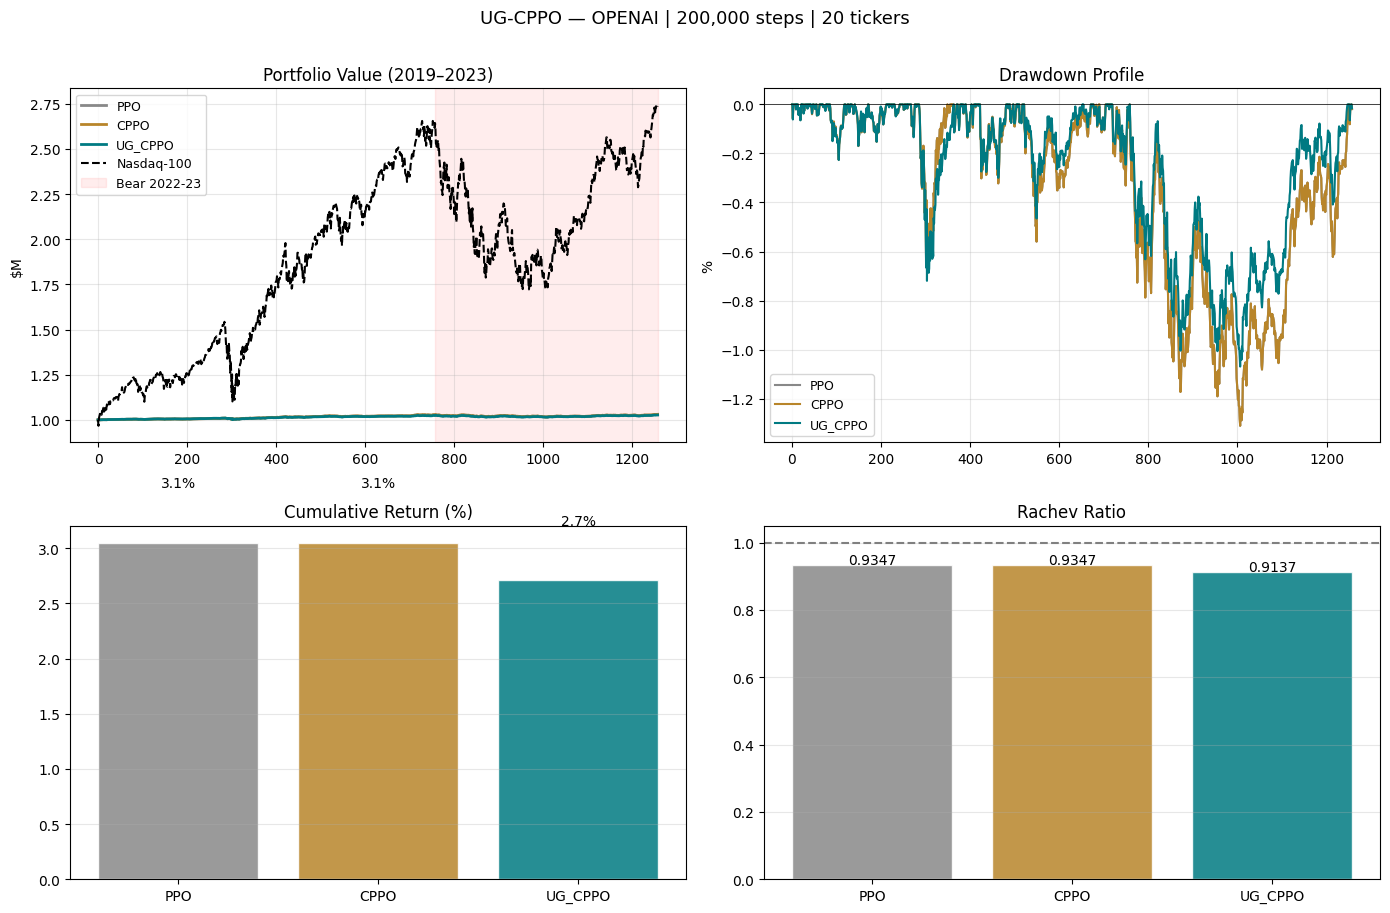

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {'ppo': '#888888', 'cppo': '#B8852A', 'ug_cppo': '#007A82'}
bv_arr = np.array(benchmark_values)

for mode in ['ppo', 'cppo', 'ug_cppo']:
    pv   = np.array(diag_results[mode]['pv_history'])
    peak = np.maximum.accumulate(pv)
    dd   = (pv - peak) / peak * 100
    axes[0,0].plot(pv/1e6,  lw=2,   color=colors[mode], label=mode.upper())
    axes[0,1].plot(dd,      lw=1.5, color=colors[mode], label=mode.upper())

n = min(len(bv_arr), len(diag_results['ppo']['pv_history']))
axes[0,0].plot(bv_arr[:n]/1e6, lw=1.5, ls='--', color='black', label='Nasdaq-100')
axes[0,0].axvspan(756, n, alpha=0.07, color='red', label='Bear 2022-23')
axes[0,0].set_title('Portfolio Value (2019–2023)'); axes[0,0].set_ylabel('$M')
axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

axes[0,1].axhline(y=0, color='black', lw=0.5)
axes[0,1].set_title('Drawdown Profile'); axes[0,1].set_ylabel('%')
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

names   = [r['model'].upper() for r in all_reports]
cumrets = [r['cumulative_return'] * 100 for r in all_reports]
rachevs = [r.get('rachev_ratio', 0) for r in all_reports]
clrs    = [colors.get(r['model'], '#666') for r in all_reports]

b1 = axes[1,0].bar(names, cumrets, color=clrs, alpha=0.85, edgecolor='white')
axes[1,0].set_title('Cumulative Return (%)'); axes[1,0].grid(axis='y', alpha=0.3)
for bar, val in zip(b1, cumrets):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}%', ha='center', fontsize=10)

b2 = axes[1,1].bar(names, rachevs, color=clrs, alpha=0.85, edgecolor='white')
axes[1,1].axhline(y=1.0, ls='--', color='gray')
axes[1,1].set_title('Rachev Ratio'); axes[1,1].grid(axis='y', alpha=0.3)
for bar, val in zip(b2, rachevs):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                   f'{val:.4f}', ha='center', fontsize=10)

plt.suptitle(f'UG-CPPO — {LLM_PROVIDER.upper()} | {TOTAL_STEPS:,} steps | 20 tickers',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Calibration Analysis

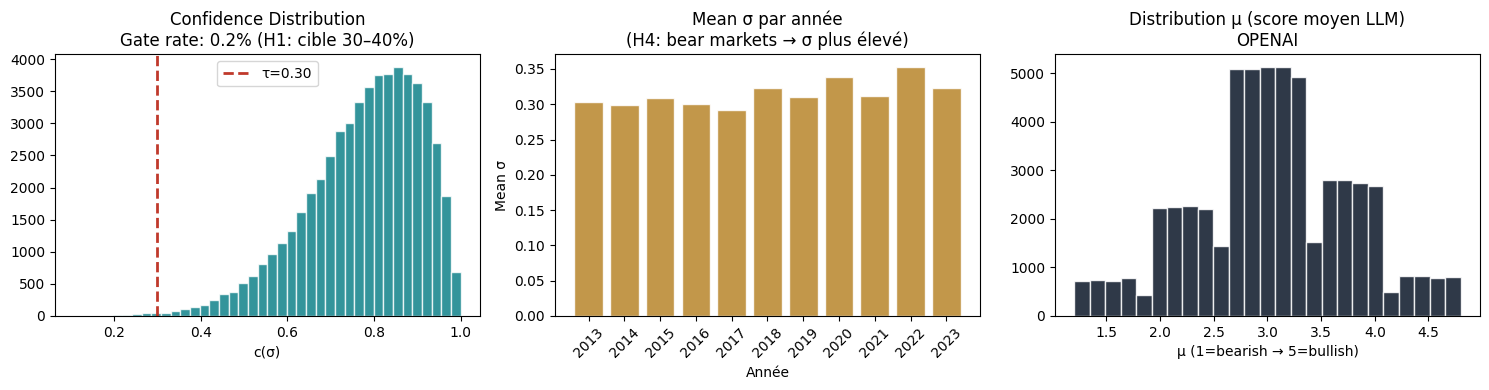

Gate rate: 0.2% | Mean σ: 0.315
σ 2022 (bear): 0.353
σ 2019 (bull): 0.311


In [12]:
sigs = pd.read_parquet(SIGNALS_PATH)
sigs['year'] = sigs['date'].str[:4]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

gate_rate = (sigs['confidence'] < 0.30).mean()
axes[0].hist(sigs['confidence'], bins=40, color='#007A82', alpha=0.8, edgecolor='white')
axes[0].axvline(x=0.30, color='#C0392B', ls='--', lw=2, label='τ=0.30')
axes[0].set_title(f'Confidence Distribution\nGate rate: {gate_rate:.1%} (H1: cible 30–40%)')
axes[0].set_xlabel('c(σ)'); axes[0].legend()

sigma_yr = sigs.groupby('year')['std_score'].mean()
axes[1].bar(sigma_yr.index, sigma_yr.values, color='#B8852A', alpha=0.85, edgecolor='white')
axes[1].set_title('Mean σ par année\n(H4: bear markets → σ plus élevé)')
axes[1].set_xlabel('Année'); axes[1].set_ylabel('Mean σ')
axes[1].tick_params(axis='x', rotation=45)

axes[2].hist(sigs['mean_score'], bins=25, color='#0A1628', alpha=0.85, edgecolor='white')
axes[2].set_title(f'Distribution μ (score moyen LLM)\n{LLM_PROVIDER.upper()}')
axes[2].set_xlabel('μ (1=bearish → 5=bullish)')

plt.tight_layout()
plt.savefig('results/calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Gate rate: {gate_rate:.1%} | Mean σ: {sigs["std_score"].mean():.3f}')
if '2022' in sigs['year'].values and '2019' in sigs['year'].values:
    print(f'σ 2022 (bear): {sigs[sigs["year"]=="2022"]["std_score"].mean():.3f}')
    print(f'σ 2019 (bull): {sigs[sigs["year"]=="2019"]["std_score"].mean():.3f}')

## 7. Upload HuggingFace

In [13]:
HF_USERNAME = 'YOUR_HF_USERNAME'
HF_REPO     = f'{HF_USERNAME}/ug-cppo-finai-2025'

# from huggingface_hub import HfApi, login
# login()
# api = HfApi()
# api.create_repo(HF_REPO, repo_type='model', exist_ok=True)
# api.upload_folder(folder_path='results/models/', repo_id=HF_REPO)
# api.create_repo(HF_REPO+'-signals', repo_type='dataset', exist_ok=True)
# api.upload_file('data/ug_signals.parquet', 'ug_signals.parquet',
#                 repo_id=HF_REPO+'-signals', repo_type='dataset')
print(f'Décommenter ci-dessus + remplacer HF_USERNAME={repr(HF_USERNAME)}')

Décommenter ci-dessus + remplacer HF_USERNAME='YOUR_HF_USERNAME'
